# 1단계 — 데이터셋 탐색

생성된 `korean_spam_dataset.csv`를 불러와 구조와 분포를 확인합니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('../data/korean_spam_dataset.csv', encoding='utf-8-sig')
print(f'총 샘플 수: {len(df)}')
df.head()

총 샘플 수: 5000


,id,subject,body,label,category
0,1,축하합니다! 에어팟 Pro 무료 증정 이벤트 당첨,"【무료증정】닌텐도 스위치 당첨 안내\n\n안녕하세요 권태양님,\n이번 달 OK캐피탈...",spam,당첨/이벤트
1,2,스포츠 토토 8.0% 적중률 보장,최수아님 안녕하세요.\n\n저희 스마트론의 스포츠 분석가가 오늘 경기를 분석했습니다...,spam,도박
2,3,Re: 지난번 말씀하신 건 관련해서요,안녕하세요!\n\n신년 모임와 관련해서 몇 가지 여쭤보고 싶은 게 있어서요.\n\n...,ham,개인/지인
3,4,[비밀] 윤도현님에게 메시지가 도착했습니다,이서연님 안녕하세요.\n\n회원님 근처에 만남을 원하는 분이 계십니다.\n지금 가입...,spam,성인/불법
4,5,[공지] 3월 정기 시스템 점검 안내,안녕하세요.\n\n쿠팡로켓와우 운영팀입니다.\n\n10월 정기 점검이 아래와 같이 ...,ham,공지/안내


## 컬럼 정보

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        5000 non-null   int64
 1   subject   5000 non-null   str  
 2   body      5000 non-null   str  
 3   label     5000 non-null   str  
 4   category  5000 non-null   str  
dtypes: int64(1), str(4)
memory usage: 195.4 KB


## 클래스 분포 (spam / ham)

label
ham     3000
spam    2000
Name: count, dtype: int64


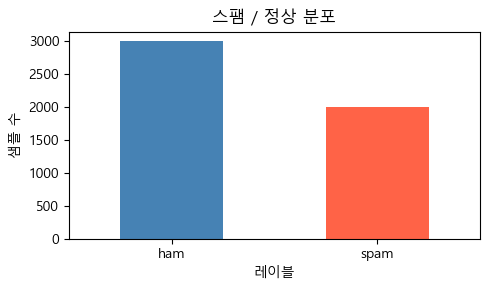

In [3]:
label_counts = df['label'].value_counts().rename({0: 'ham', 1: 'spam'})
print(label_counts)

label_counts.plot(kind='bar', color=['steelblue', 'tomato'], figsize=(5, 3))
plt.title('스팸 / 정상 분포')
plt.xlabel('레이블')
plt.ylabel('샘플 수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 카테고리별 분포

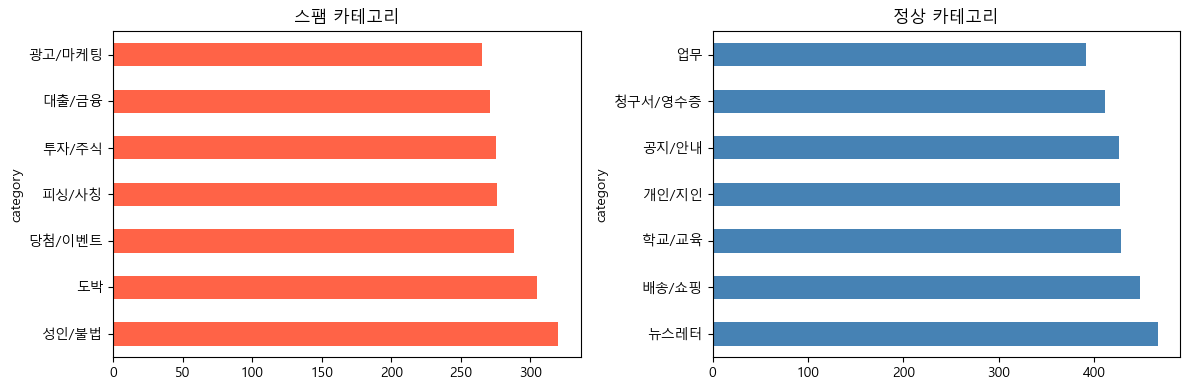

In [6]:
spam_df = df[df['label'] == 'spam']
ham_df  = df[df['label'] == 'ham']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

spam_df['category'].value_counts().plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('스팸 카테고리')

ham_df['category'].value_counts().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('정상 카테고리')

plt.tight_layout()
plt.show()

## 텍스트 길이 분포

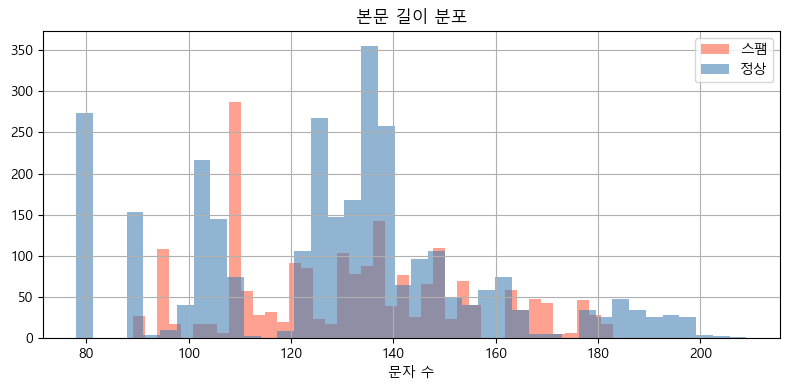

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    3000.0  128.233333  28.211656  78.0  105.0  131.0  141.0  209.0
spam   2000.0  132.561500  22.819938  89.0  111.0  133.0  149.0  183.0


In [8]:
df['body_len'] = df['body'].str.len()

fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [('spam', 'tomato', '스팸'), ('ham', 'steelblue', '정상')]:
    df[df['label'] == label]['body_len'].hist(
        bins=40, alpha=0.6, color=color, label=name, ax=ax
    )
ax.set_title('본문 길이 분포')
ax.set_xlabel('문자 수')
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby('label')['body_len'].describe())

## 샘플 확인

In [10]:
print('=== 스팸 샘플 ===')
sample = df[df['label'] == 'spam'].sample(1, random_state=0).iloc[0]
print(f'[카테고리] {sample["category"]}')
print(f'[제목] {sample["subject"]}')
print(f'[본문] {sample["body"][:200]}...')

print('\n=== 정상 샘플 ===')
sample = df[df['label'] == 'ham'].sample(1, random_state=0).iloc[0]
print(f'[카테고리] {sample["category"]}')
print(f'[제목] {sample["subject"]}')
print(f'[본문] {sample["body"][:200]}...')

=== 스팸 샘플 ===
[카테고리] 피싱/사칭
[제목] [법원] 민사소송 출석 요구서 발송
[본문] 안녕하세요, 김민준님.

[카카오 고객센터]

회원님의 계정에서 비정상적인 접속이 감지되었습니다.
보안을 위해 즉시 아래 링크에서 본인인증을 해주세요.

▶ 본인인증 링크: http://tinyurl.com/spam123

24시간 내 인증하지 않으면 계정이 잠금 처리됩니다....

=== 정상 샘플 ===
[카테고리] 업무
[제목] 금주 업무 보고 드립니다
[본문] 안녕하세요, 윤도현님.

마케팅 캠페인 관련하여 검토가 필요한 사항이 있어 연락드립니다.

첨부 파일을 확인하시고 2024년 11월 01일까지 피드백 부탁드립니다.

감사합니다.
이대리 드림...
